In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
survey_raw=pd.read_csv("Data/survey_results_public.csv")

In [9]:
survey_raw

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89179,89180,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Bootstrapping a business;Freelance/contr...,"Associate degree (A.A., A.S., etc.)",Online Courses or Certification;Other online r...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN
89180,89181,I agree,I am a developer by profession,18-24 years old,"Student, full-time;Employed, part-time","Hybrid (some remote, some in-person)",School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Online Courses or Certification;Othe...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN
89181,89182,I agree,I code primarily as a hobby,Prefer not to say,I prefer not to say,NaN,NaN,Something else,Books / Physical media;Hackathons (virtual or ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN
89182,89183,I agree,I am a developer by profession,Under 18 years old,"Employed, part-time;Student, part-time","Hybrid (some remote, some in-person)",Hobby;School or academic work,"Secondary school (e.g. American high school, G...",Online Courses or Certification;Other online r...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN


In [10]:
survey_raw.iloc[0]

ResponseId                           1
Q120                           I agree
MainBranch               None of these
Age                    18-24 years old
Employment                         NaN
                            ...       
ProfessionalTech                   NaN
Industry                           NaN
SurveyLength                       NaN
SurveyEase                         NaN
ConvertedCompYearly                NaN
Name: 0, Length: 84, dtype: object

In [11]:
#drop record 0 since majority values are NaN
survey_raw.drop(0,axis=0,inplace=True)

In [15]:
 survey_raw

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0
5,6,I agree,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;Colleague;Online Course...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,30-60 minutes a day,15-30 minutes a day,DevOps function;Microservices;Observability to...,Other,Appropriate in length,Neither easy nor difficult,96828.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89179,89180,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Bootstrapping a business;Freelance/contr...,"Associate degree (A.A., A.S., etc.)",Online Courses or Certification;Other online r...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN
89180,89181,I agree,I am a developer by profession,18-24 years old,"Student, full-time;Employed, part-time","Hybrid (some remote, some in-person)",School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Online Courses or Certification;Othe...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN
89181,89182,I agree,I code primarily as a hobby,Prefer not to say,I prefer not to say,NaN,NaN,Something else,Books / Physical media;Hackathons (virtual or ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN
89182,89183,I agree,I am a developer by profession,Under 18 years old,"Employed, part-time;Student, part-time","Hybrid (some remote, some in-pe

Datsaet has over 89000 rows and 84 columns

In [18]:
survey_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89183 entries, 1 to 89183
Data columns (total 84 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ResponseId                           89183 non-null  int64  
 1   Q120                                 89183 non-null  object 
 2   MainBranch                           89183 non-null  object 
 3   Age                                  89183 non-null  object 
 4   Employment                           87898 non-null  object 
 5   RemoteWork                           73810 non-null  object 
 6   CodingActivities                     73764 non-null  object 
 7   EdLevel                              87973 non-null  object 
 8   LearnCode                            87663 non-null  object 
 9   LearnCodeOnline                      70084 non-null  object 
 10  LearnCodeCoursesCert                 37076 non-null  object 
 11  YearsCode                   

A pandas Series containing the 'question' column, with 'qname' serving as the index. You can access individual questions using the corresponding 'qname'.

In [22]:
schema_raw=pd.read_csv("Data/survey_results_schema.csv",index_col='qname').question

In [23]:
schema_raw

qname
S0             <div><span style="font-size:19px;"><strong>Hel...
MetaInfo                                       Browser Meta Info
Q310           <div><span style="font-size:19px;"><strong>You...
Q120                                                            
S1             <span style="font-size:22px; font-family: aria...
                                     ...                        
Knowledge_7    Waiting on answers to questions often causes i...
Knowledge_8    I feel like I have the tools and/or resources ...
Frequency_1    Needing help from people outside of your immed...
Frequency_2    Interacting with people outside of your immedi...
Frequency_3    Encountering knowledge silos (where one indivi...
Name: question, Length: 78, dtype: object

In [24]:
schema_raw['Employment']

'Which of the following best describes your current employment status? Select all that apply.'

## Data Cleaning and Preprocessing

The survey responses a wealth of infromation therefore we are going to limit out 
analysis to some following areas:
1. Demographics
2. Distribution of Skills
3. Employment Realted Info

In [39]:
selected_cols=['MainBranch',
              'Employment',
              'RemoteWork',
              'CodingActivities',
              'EdLevel',
              'LearnCode',
              'LearnCodeOnline',
              'LearnCodeCoursesCert',
              'YearsCode',
              'YearsCodePro',
              'DevType',
              'OrgSize',
              'PurchaseInfluence',
              'BuyNewTool',
              'Country',
              'Currency',
              'CompTotal',
              'LanguageHaveWorkedWith',
              'LanguageWantToWorkWith',
              'PlatformHaveWorkedWith',
              'TBranch',
              'ICorPM',
              'WorkExp',
              'TimeSearching',
              'TimeAnswering',
              'ProfessionalTech',
              'ConvertedCompYearly',
              'PlatformWantToWorkWith',
              'NEWSOSites',
              'SOVisitFreq',
              'SOComm',
              'Age',
              'SOPartFreq',
              'SOAccount']


In [40]:
len(selected_cols)

34

In [41]:
survey_df=survey_raw[selected_cols].copy()

In [42]:
survey_df

,MainBranch,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,LearnCodeCoursesCert,YearsCode,YearsCodePro,...,TimeAnswering,ProfessionalTech,ConvertedCompYearly,PlatformWantToWorkWith,NEWSOSites,SOVisitFreq,SOComm,Age,SOPartFreq,SOAccount
1,I am a developer by profession,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,Other,18,9,...,15-30 minutes a day,DevOps function;Microservices;Automated testin...,285000.0,Fly.io;Netlify;Render,Stack Overflow;Stack Exchange,Daily or almost daily,"Yes, definitely",25-34 years old,A few times per month or weekly,Yes
2,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,NaN,27,23,...,30-60 minutes a day,DevOps function;Microservices;Automated testin...,250000.0,NaN,Stack Overflow;Stack Exchange;Stack Overflow f...,A few times per month or weekly,Neutral,45-54 years old,Less than once per month or monthly,Yes
3,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,NaN,12,7,...,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,156000.0,Cloudflare;Heroku,Stack Overflow;Stack Exchange,A few times per week,"No, not really",25-34 years old,Less than once per month or monthly,Yes
4,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,Other;Codecademy;edX,6,4,...,30-60 minutes a day,Microservices;Automated testing;Observability ...,23456.0,Amazon Web Services (AWS);Cloudflare;Digital O...,Stack Overflow;Stack Exchange,A few times per week,Neutral,25-34 years old,NaN,No
5,I am a developer by profession,"Employed, full-time",Remote,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;Colleague;Online Course...,Formal documentation provided by the owner of ...,Other,21,21,...,15-30 minutes a day,DevOps function;Microservices;Observability to...,96828.0,NaN,Stack Overflow,Daily or almost daily,"No, not at all",35-44 years old,I have never participated in Q&A on Stack Over...,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89179,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Bootstrapping a business;Freelance/contr...,"Associate degree (A.A., A.S., etc.)",Online Courses or Certification;Other online r...,Formal documentation provided by the owner of ...,Udemy,20,5,...,NaN,NaN,NaN,Amazon Web Services (AWS);Heroku;Netlify;Vercel,Stack Overflow;Stack Exchange,Multiple times per day,Neutral,25-34 years old,I have never participated in Q&A on Stack Over...,Yes
89180,I am a developer by profession,"Student, full-time;Employed, part-time","Hybrid (some remote, some in-person)",School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Online Courses or Certification;Othe...,Formal documentation provided by the owner of ...,NaN,5,NaN,...,NaN,NaN,NaN,NaN,Stack Overflow;Stack Exchange,Multiple times per day,"No, not really",18-24 years old,I have never participated in Q&A on Stack Over...,Yes
89181,I code primarily as a hobby,I prefer not to say,NaN,NaN,Something else,Books / Physical media;Hackathons (virtual or ...,NaN,Codecademy;Coursera,10,NaN,...,NaN,NaN,NaN,Amaz

In [43]:
survey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89183 entries, 1 to 89183
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MainBranch              89183 non-null  object 
 1   Employment              87898 non-null  object 
 2   RemoteWork              73810 non-null  object 
 3   CodingActivities        73764 non-null  object 
 4   EdLevel                 87973 non-null  object 
 5   LearnCode               87663 non-null  object 
 6   LearnCodeOnline         70084 non-null  object 
 7   LearnCodeCoursesCert    37076 non-null  object 
 8   YearsCode               87435 non-null  object 
 9   YearsCodePro            66136 non-null  object 
 10  DevType                 76872 non-null  object 
 11  OrgSize                 65043 non-null  object 
 12  PurchaseInfluence       64964 non-null  object 
 13  BuyNewTool              83009 non-null  object 
 14  Country                 87973 non-null

In [53]:
survey_df.YearsCode.value_counts()

YearsCode
10.0    6521
5.0     5415
6.0     4893
8.0     4879
7.0     4800
4.0     4466
15.0    4336
3.0     4269
20.0    4021
12.0    3471
9.0     3130
2.0     2826
25.0    2685
13.0    2601
11.0    2519
14.0    2278
30.0    2078
16.0    1842
18.0    1690
17.0    1544
23.0    1327
40.0    1302
1.0     1294
22.0    1210
35.0    1118
24.0     959
19.0     826
21.0     761
28.0     715
27.0     710
26.0     706
33.0     496
32.0     444
38.0     428
45.0     360
42.0     347
34.0     333
29.0     324
37.0     312
36.0     282
31.0     272
43.0     265
39.0     229
41.0     227
44.0     160
50.0     125
46.0     101
48.0      96
47.0      79
49.0      42
Name: count, dtype: int64

In [62]:
#convert object to int
survey_df['YearsCode']=pd.to_numeric(survey_df.YearsCode,errors='coerce')

In [70]:
survey_df.YearsCode.value_counts()

YearsCode
10.0    6521
5.0     5415
6.0     4893
8.0     4879
7.0     4800
4.0     4466
15.0    4336
3.0     4269
20.0    4021
12.0    3471
9.0     3130
2.0     2826
25.0    2685
13.0    2601
11.0    2519
14.0    2278
30.0    2078
16.0    1842
18.0    1690
17.0    1544
23.0    1327
40.0    1302
1.0     1294
22.0    1210
35.0    1118
24.0     959
19.0     826
21.0     761
28.0     715
27.0     710
26.0     706
33.0     496
32.0     444
38.0     428
45.0     360
42.0     347
34.0     333
29.0     324
37.0     312
36.0     282
31.0     272
43.0     265
39.0     229
41.0     227
44.0     160
50.0     125
46.0     101
48.0      96
47.0      79
49.0      42
Name: count, dtype: int64

In [77]:
survey_df['YearsCodePro']=pd.to_numeric(survey_df.YearsCodePro,errors='coerce')

In [83]:
survey_df.YearsCodePro.value_counts()

YearsCodePro
5.0     4792
10.0    4594
2.0     4464
3.0     4378
4.0     3970
6.0     3637
7.0     3509
8.0     3462
15.0    2789
1.0     2596
12.0    2398
20.0    2227
9.0     2145
11.0    2013
13.0    1690
25.0    1449
16.0    1278
14.0    1256
18.0    1212
17.0    1146
23.0    1112
30.0     924
22.0     845
24.0     686
19.0     649
21.0     565
27.0     490
26.0     486
35.0     462
28.0     417
40.0     329
32.0     293
33.0     264
29.0     217
36.0     200
31.0     187
34.0     177
38.0     164
37.0     150
45.0     102
39.0      99
42.0      81
41.0      79
43.0      67
44.0      42
46.0      33
48.0      30
47.0      24
50.0      24
49.0      14
Name: count, dtype: int64

In [88]:
survey_df.describe()

,YearsCode,YearsCodePro,CompTotal,WorkExp,ConvertedCompYearly
count,86114.000000,64217.000000,4.822500e+04,43579.000000,4.801900e+04
mean,13.972049,11.508354,1.036807e+42,11.405126,1.031101e+05
std,10.259548,9.070346,2.276847e+44,9.051989,6.814188e+05
min,1.000000,1.000000,0.000000e+00,0.000000,1.000000e+00
25%,6.000000,5.000000,6.300000e+04,5.000000,4.390700e+04
50%,11.000000,9.000000,1.150000e+05,9.000000,7.496300e+04
75%,20.000000,16.000000,2.300000e+05,16.000000,1.216410e+05
max,50.000000,50.000000,5.000000e+46,50.000000,7.435143e+07


In [92]:
#value counts for all
for column in survey_df.columns:
    print(survey_df[column].value_counts())

MainBranch
I am a developer by profession                                                           67237
I am not primarily a developer, but I write code sometimes as part of my work/studies     8954
I am learning to code                                                                     4961
I code primarily as a hobby                                                               4960
I used to be a developer by profession, but no longer am                                  1861
None of these                                                                             1210
Name: count, dtype: int64
Employment
Employed, full-time                                                                                                                                                                                             53748
Student, full-time                                                                                                                                                      

In employemnt some values have mutlipl options therefore we use split multicolumn function
A multicolumn funtion will make a new column for every choice available 
ie. one for employee, one for full-time,etc
for every row marks True or False

In [100]:
'''for every entry in colum we split it about the ; and then keep all unique values coming in the whole column as the headers and m
make true in the row which they appear and false otherwise'''

def split_multicolumn(col_series):
    result_df=col_series.to_frame()
    options=[]
    #Iterate over the columns
    for idx, value in col_series[col_series.notnull()].items():
        #Break each value into list of options
        for option in value.split(';'):
            #Add option as a column to result
            if not option in result_df.columns:
                options.append(option)
                result_df[option]=False
            #Mark the value in the option column as True
            result_df.at[idx,option]=True
    return result_df[options]

In [101]:
employment_type_df=split_multicolumn(survey_df.Employment)

In [102]:
employment_type_df

,"Employed, full-time","Independent contractor, freelancer, or self-employed","Not employed, but looking for work","Student, full-time","Employed, part-time","Student, part-time",I prefer not to say,Retired,"Not employed, and not looking for work"
1,True,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False
4,True,True,False,False,False,False,False,False,False
5,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
89179,True,True,False,False,False,False,False,False,False
89180,False,False,False,True,True,False,False,False,False
89181,False,False,False,False,False,False,True,False,False
89182,False,False,False,False,True,True,False,False,False


In [103]:
employment_type_totals=employment_type_df.sum().sort_values(ascending=False)

In [104]:
employment_type_totals

Employed, full-time                                     60899
Independent contractor, freelancer, or self-employed    13988
Student, full-time                                      11768
Employed, part-time                                      5029
Not employed, but looking for work                       4178
Student, part-time                                       3390
Not employed, and not looking for work                   1380
Retired                                                   737
I prefer not to say                                       549
dtype: int64

## Univariate Analysis

In [124]:
survey_df.MainBranch.value_counts()

MainBranch
I am a developer by profession                                                           67237
I am not primarily a developer, but I write code sometimes as part of my work/studies     8954
I am learning to code                                                                     4961
I code primarily as a hobby                                                               4960
I used to be a developer by profession, but no longer am                                  1861
None of these                                                                             1210
Name: count, dtype: int64

<Axes: xlabel='MainBranch', ylabel='count'>

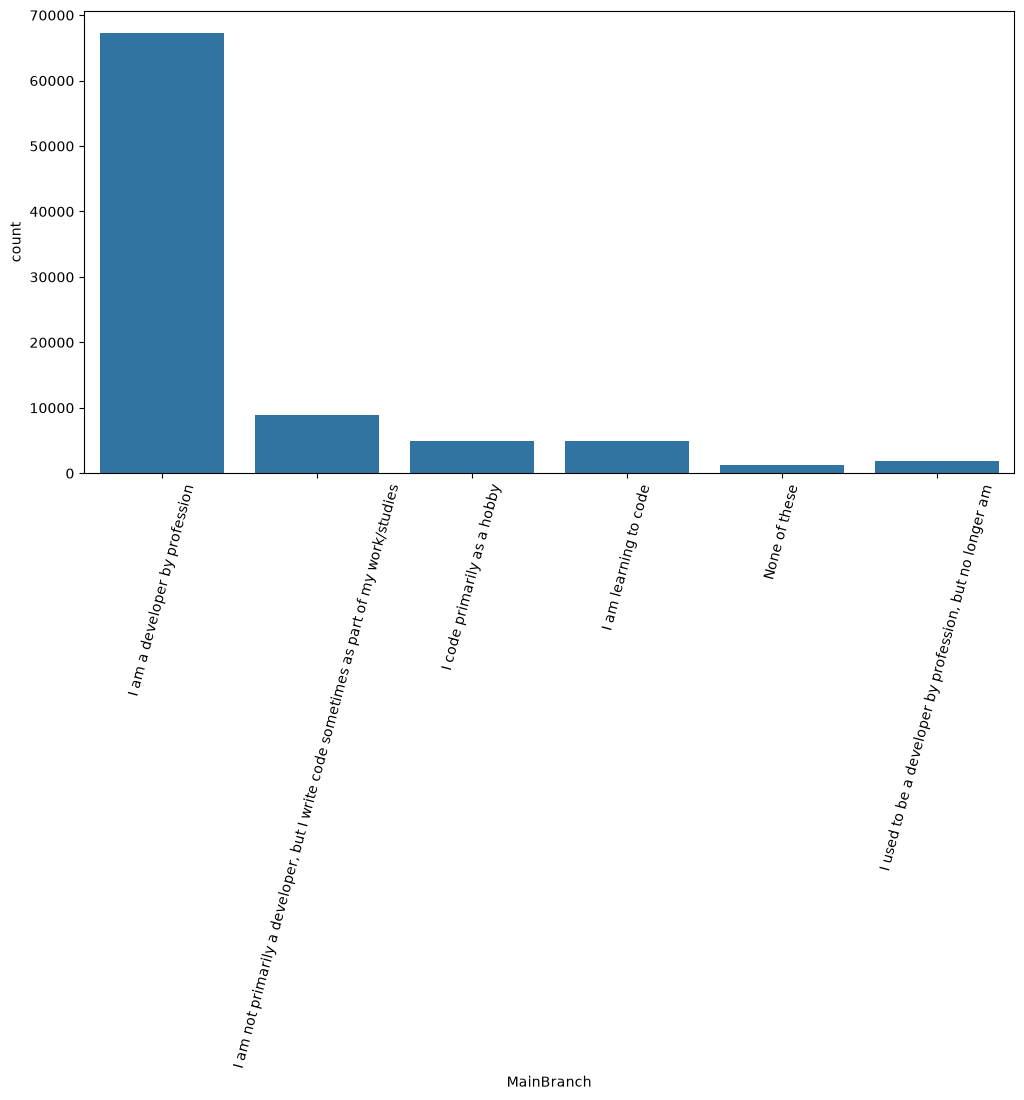

In [125]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.countplot(x=survey_df.MainBranch)

In [126]:
survey_df.Employment.value_counts()

Employment
Employed, full-time                                                                                                                                                                                             53748
Student, full-time                                                                                                                                                                                               7430
Independent contractor, freelancer, or self-employed                                                                                                                                                             7076
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                                                                                         4354
Not employed, but looking for work                                                                                                   

In [127]:
employment_type_totals

Employed, full-time                                     60899
Independent contractor, freelancer, or self-employed    13988
Student, full-time                                      11768
Employed, part-time                                      5029
Not employed, but looking for work                       4178
Student, part-time                                       3390
Not employed, and not looking for work                   1380
Retired                                                   737
I prefer not to say                                       549
dtype: int64

<Axes: xlabel='None', ylabel='None'>

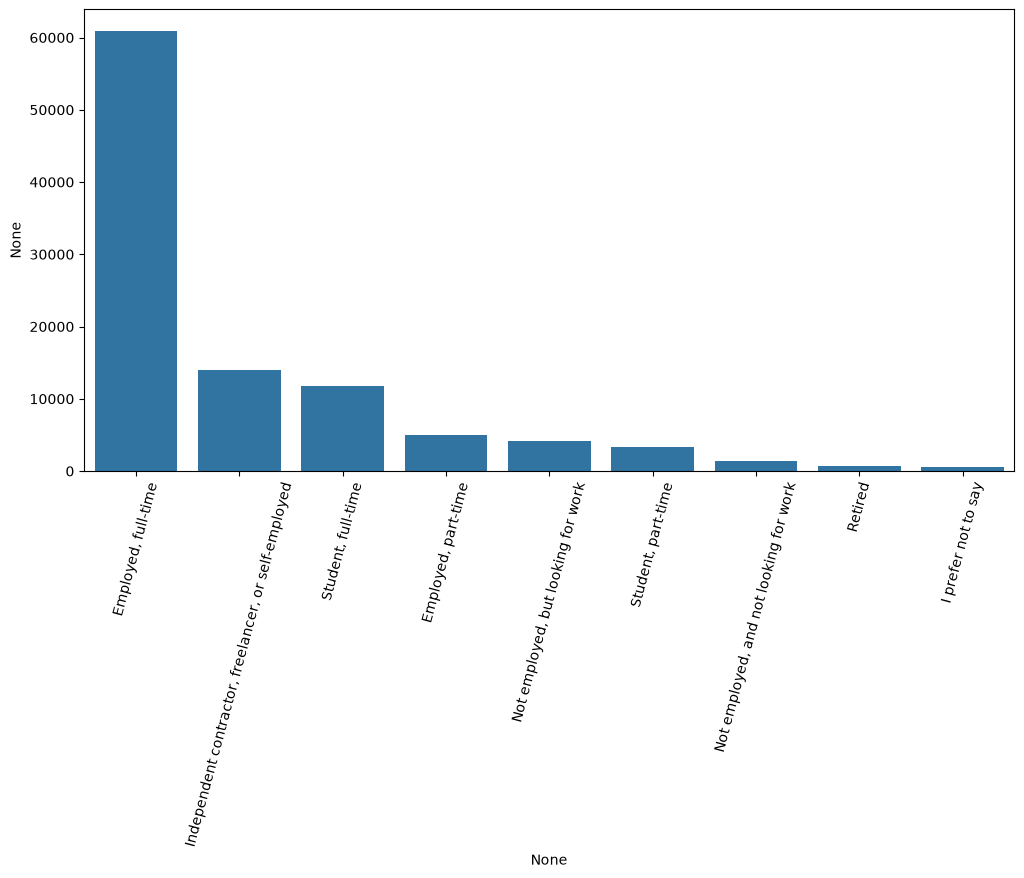

In [128]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.barplot(x=employment_type_totals.index,y=employment_type_totals)

In [129]:
survey_df.RemoteWork.value_counts()

RemoteWork
Hybrid (some remote, some in-person)    31131
Remote                                  30566
In-person                               12113
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='RemoteWork'>

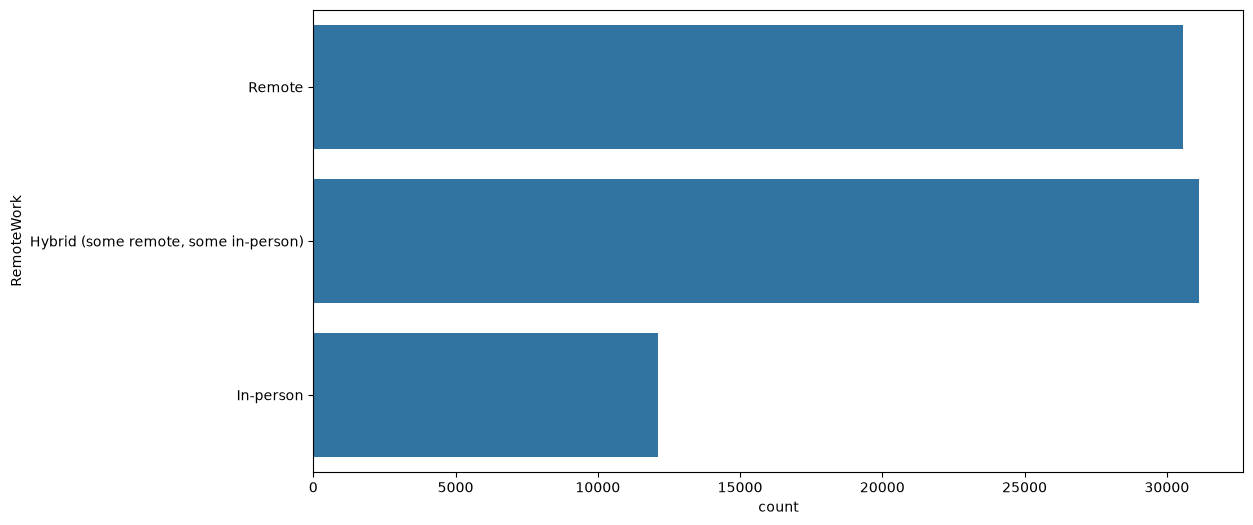

In [130]:
plt.figure(figsize=(12,6))
sns.countplot(survey_df.RemoteWork)

<Axes: xlabel='count', ylabel='EdLevel'>

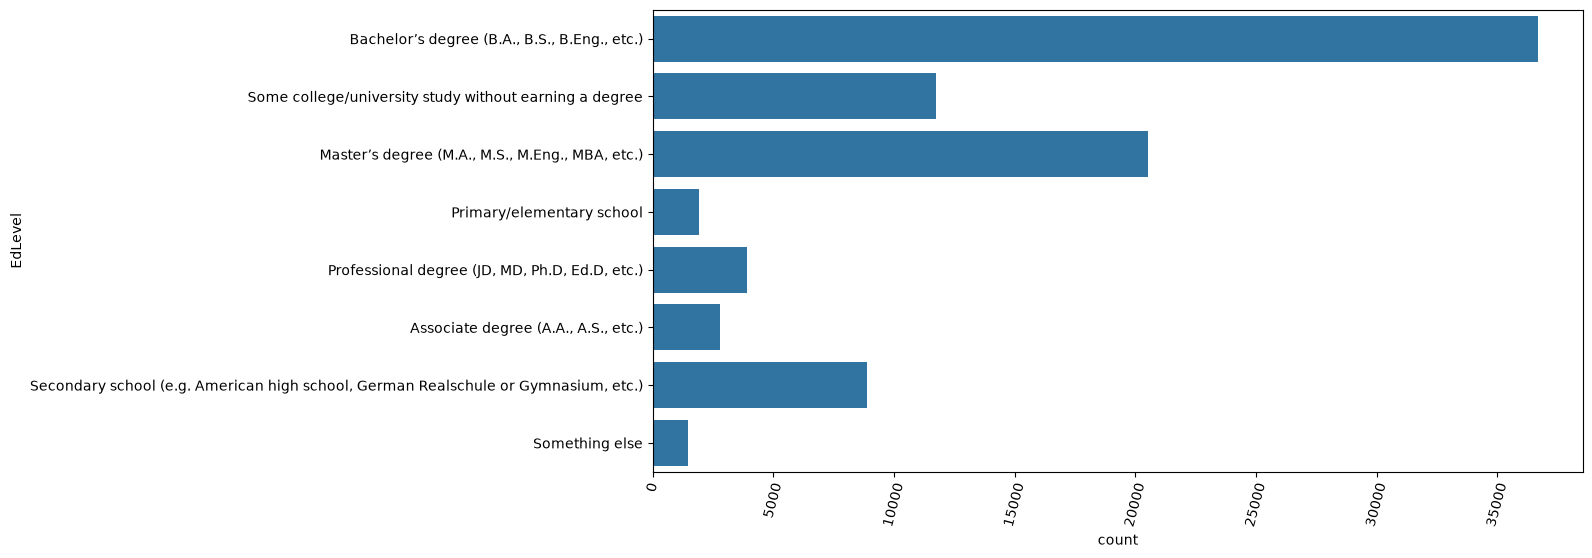

In [131]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.countplot(survey_df.EdLevel)

In [132]:
country_count=survey_df.Country.value_counts().sort_values(ascending=False).head(10)

<Axes: xlabel='Country', ylabel='count'>

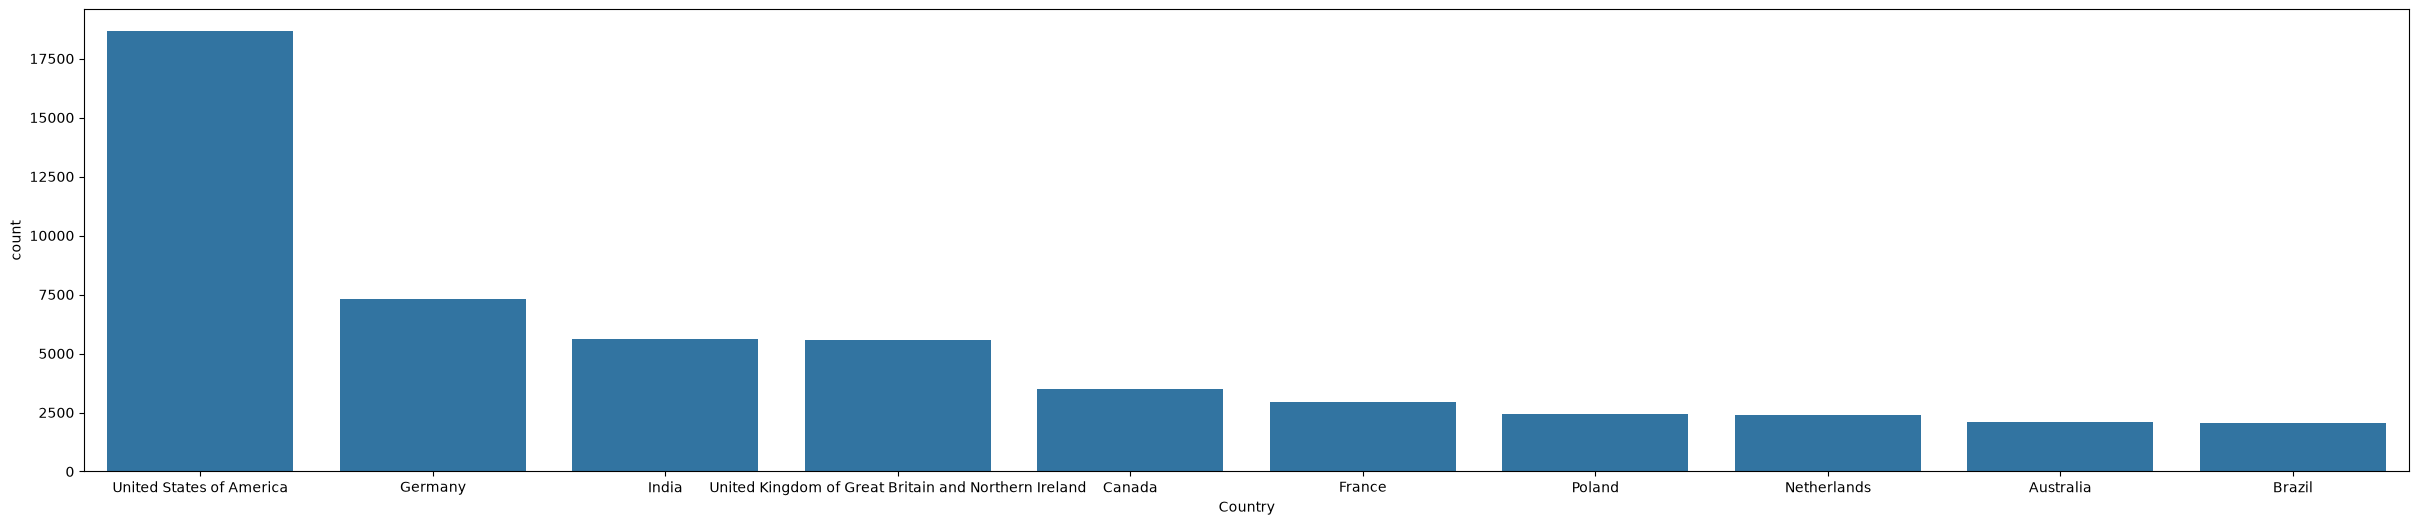

In [133]:
plt.figure(figsize=(30,6))
sns.barplot(x=country_count.index,y=country_count)

In [134]:
survey_df.Age.value_counts().sort_values(ascending=False)

Age
25-34 years old       33247
35-44 years old       20532
18-24 years old       17930
45-54 years old        8334
Under 18 years old     4128
55-64 years old        3392
65 years or older      1171
Prefer not to say       449
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Age'>

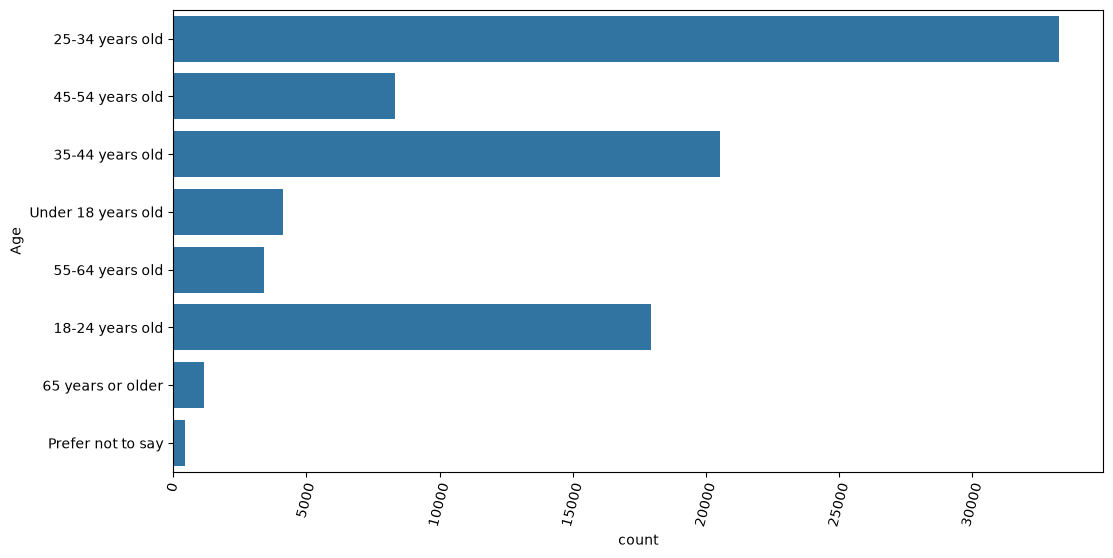

In [135]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.countplot(survey_df.Age)

using historgrams for numerical values is a wise choice since there are so many values

<Axes: xlabel='YearsCode', ylabel='Count'>

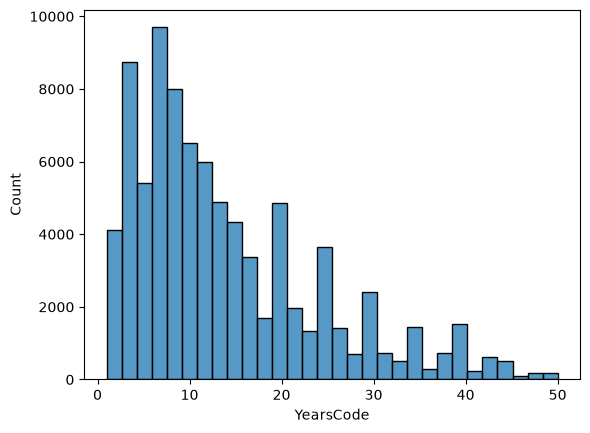

In [143]:
sns.histplot(survey_df.YearsCode,bins=30)

<Axes: xlabel='WorkExp', ylabel='Count'>

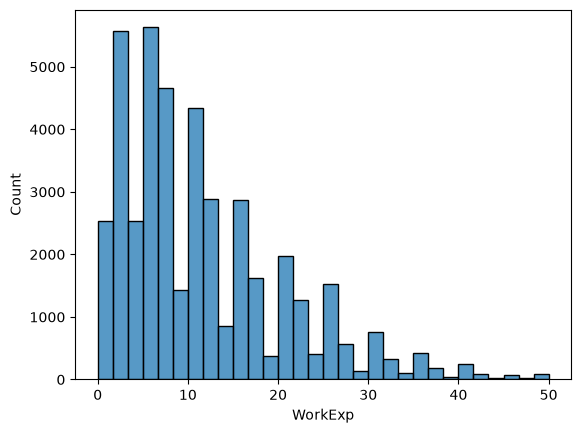

In [150]:
sns.histplot(survey_df.WorkExp,bins=30)

## Bivariate Analysis

In [156]:
survey_df.columns

Index(['MainBranch', 'Employment', 'RemoteWork', 'CodingActivities', 'EdLevel',
       'LearnCode', 'LearnCodeOnline', 'LearnCodeCoursesCert', 'YearsCode',
       'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool',
       'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'PlatformHaveWorkedWith', 'TBranch', 'ICorPM',
       'WorkExp', 'TimeSearching', 'TimeAnswering', 'ProfessionalTech',
       'ConvertedCompYearly', 'PlatformWantToWorkWith', 'NEWSOSites',
       'SOVisitFreq', 'SOComm', 'Age', 'SOPartFreq', 'SOAccount'],
      dtype='object')

In [157]:
a=split_multicolumn(survey_df.LanguageHaveWorkedWith).sum().sort_values(ascending=False)

In [158]:
b=split_multicolumn(survey_df.LanguageWantToWorkWith).sum().sort_values(ascending=False)

In [159]:
#combine columnwise
combined_df=pd.concat([a,b],axis=1)
combined_df.columns=['WorkedWith','WantToWorkWith']

<Axes: >

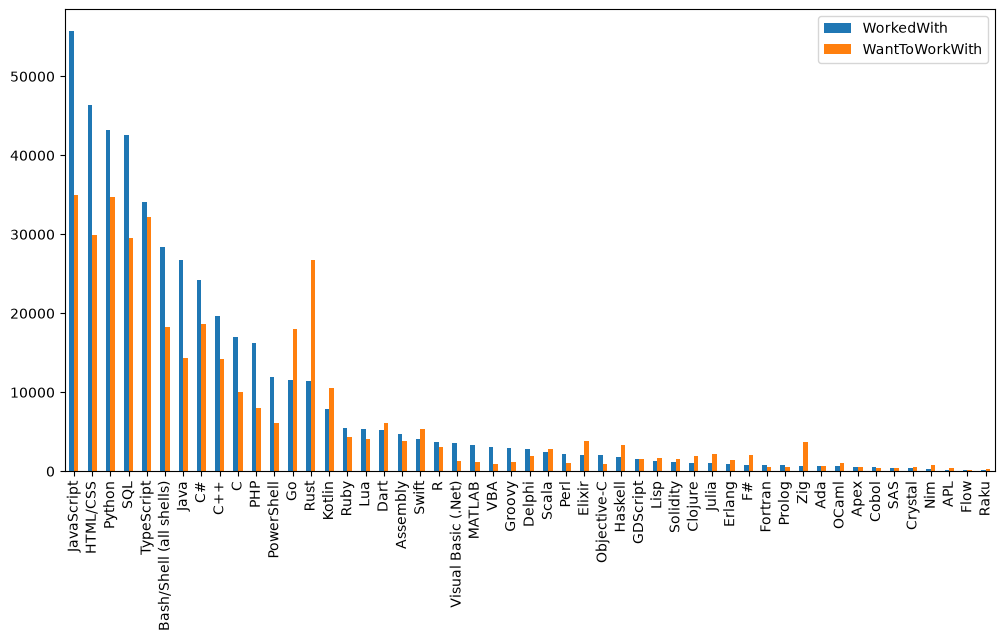

In [173]:
combined_df.plot(kind='bar',figsize=(12,6))

In [174]:
c=split_multicolumn(survey_df.PlatformHaveWorkedWith).sum().sort_values(ascending=False)

In [175]:
d=split_multicolumn(survey_df.PlatformWantToWorkWith).sum().sort_values(ascending=False)

<Axes: >

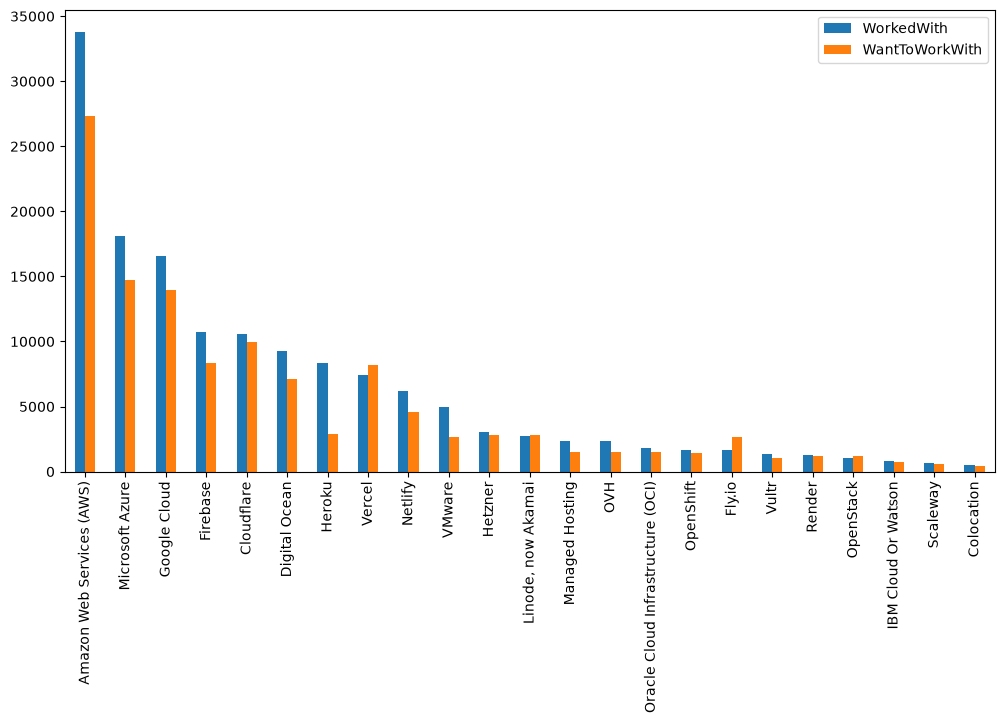

In [176]:
#combine columnwise
combined2_df=pd.concat([c,d],axis=1)
combined2_df.columns=['WorkedWith','WantToWorkWith']
combined2_df.plot(kind='bar',figsize=(12,6))

AWS is the most popular platoform currently

<Axes: xlabel='MainBranch', ylabel='count'>

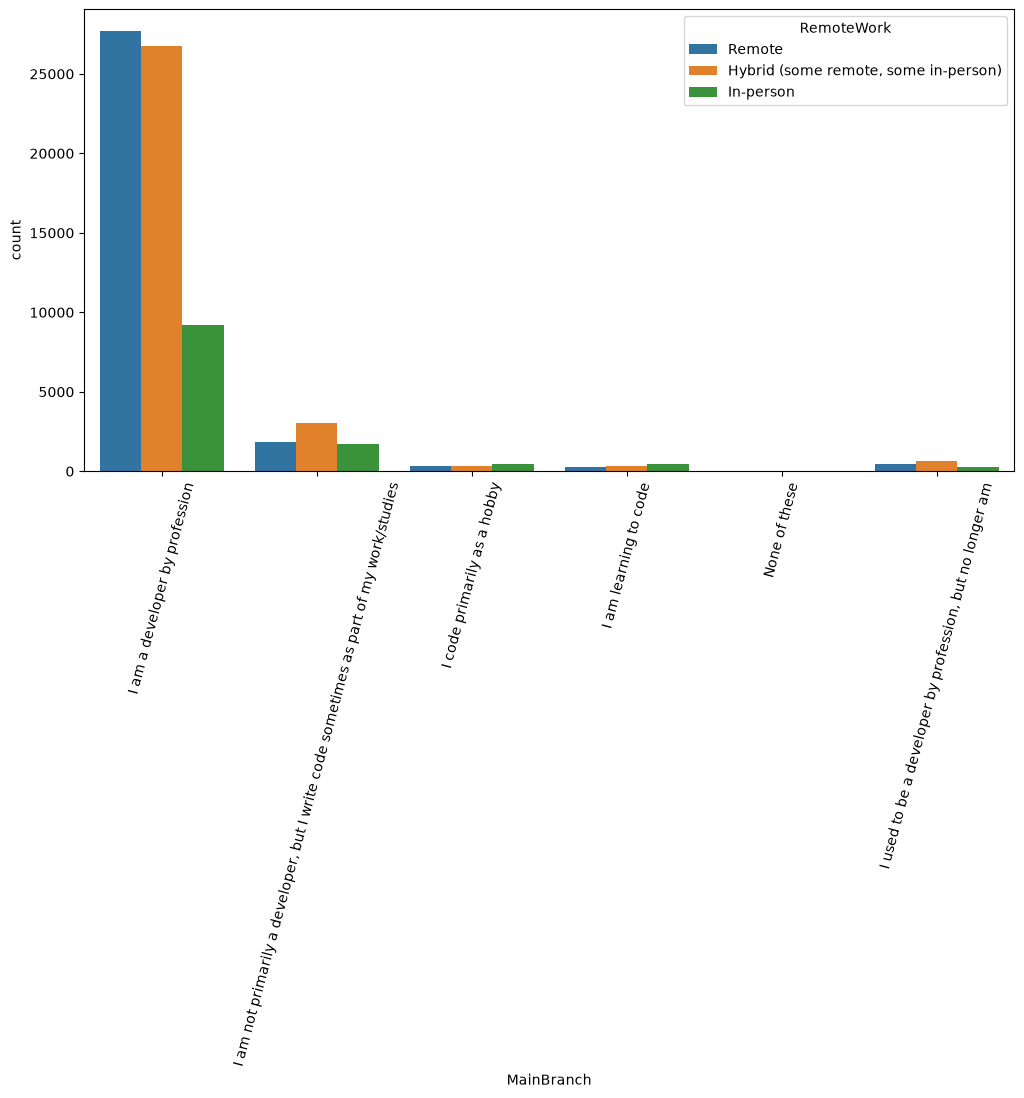

In [177]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.countplot(x=survey_df.MainBranch,hue=survey_df.RemoteWork)

Most professional developers work remotly

<Axes: xlabel='EdLevel', ylabel='YearsCode'>

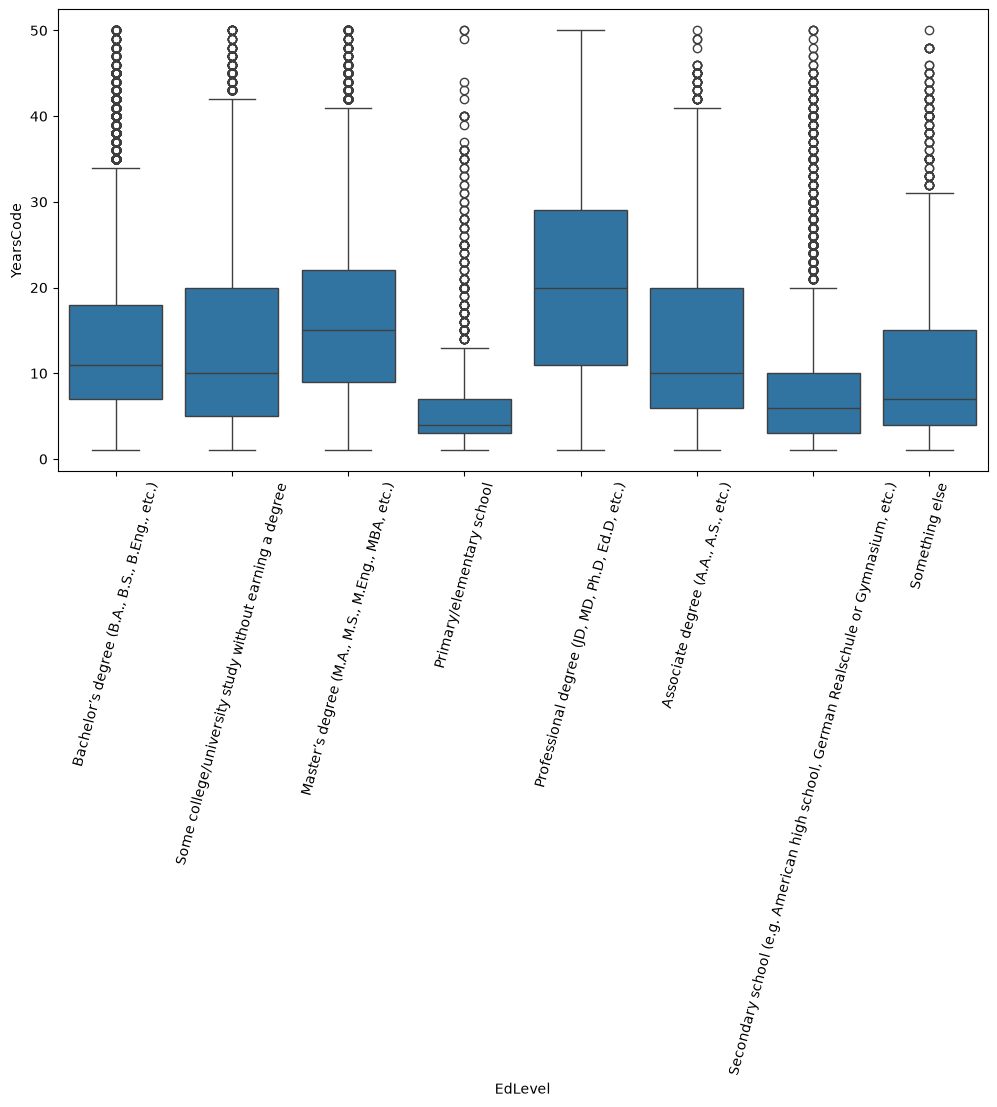

In [178]:
#use box plot because EdLevel--Categorical and Years--numerical, understand bifercation
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.boxplot(x=survey_df.EdLevel,y=survey_df.YearsCode)

The bachelor's degree has a lower IQR than Masters' , that shows that the people with
Masters' Degree have more experinece
Also other doctoral degree has highest experinece